In [23]:
# Standard Library
import os
import sys
import json
import math
import time
import shutil
from pathlib import Path
from collections import Counter

# Third-Party Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import kagglehub
from ultralytics import YOLO

# PyTorch Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [2]:
pathCF = kagglehub.dataset_download("tuyenldvn/caucafall")

print("Path to dataset files:", pathCF)

100%|██████████| 7.76G/7.76G [01:28<00:00, 94.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tuyenldvn/caucafall/versions/2


In [3]:
#-------------------------------------------------------------------------------
# Copying datasets into content/ from session's cache/
#-------------------------------------------------------------------------------

# Source directories
CFALL_SRC = "/root/.cache/kagglehub/datasets/tuyenldvn/caucafall/versions/2/Dataset CAUCAFall/CAUCAFall"
# Target directories
CFALL_DST = "/content/CAUCA_FALL"

def move_dataset(src, dst):
    if os.path.exists(dst):
        print(f"{dst} already exists. Skipping copy.")
    else:
        shutil.copytree(src, dst)
        print(f"Copied dataset to {dst}")

# Move datasets
move_dataset(CFALL_SRC, CFALL_DST)


Copied dataset to /content/CAUCA_FALL


Logits: [[   -0.50418     0.54758]]
Raw Saliency: [  0.0028674    0.012092    0.021317    0.029834    0.038299    0.090771     0.15001     0.26394     0.39154     0.35261     0.25313     0.16294    0.077411    0.038309    0.030159    0.022783    0.016084    0.011478   0.0092618    0.007746   0.0072802   0.0068795   0.0066089   0.0064006   0.0063635   0.0063875
   0.0066561   0.0069164    0.007123    0.007224   0.0058454   0.0044667]


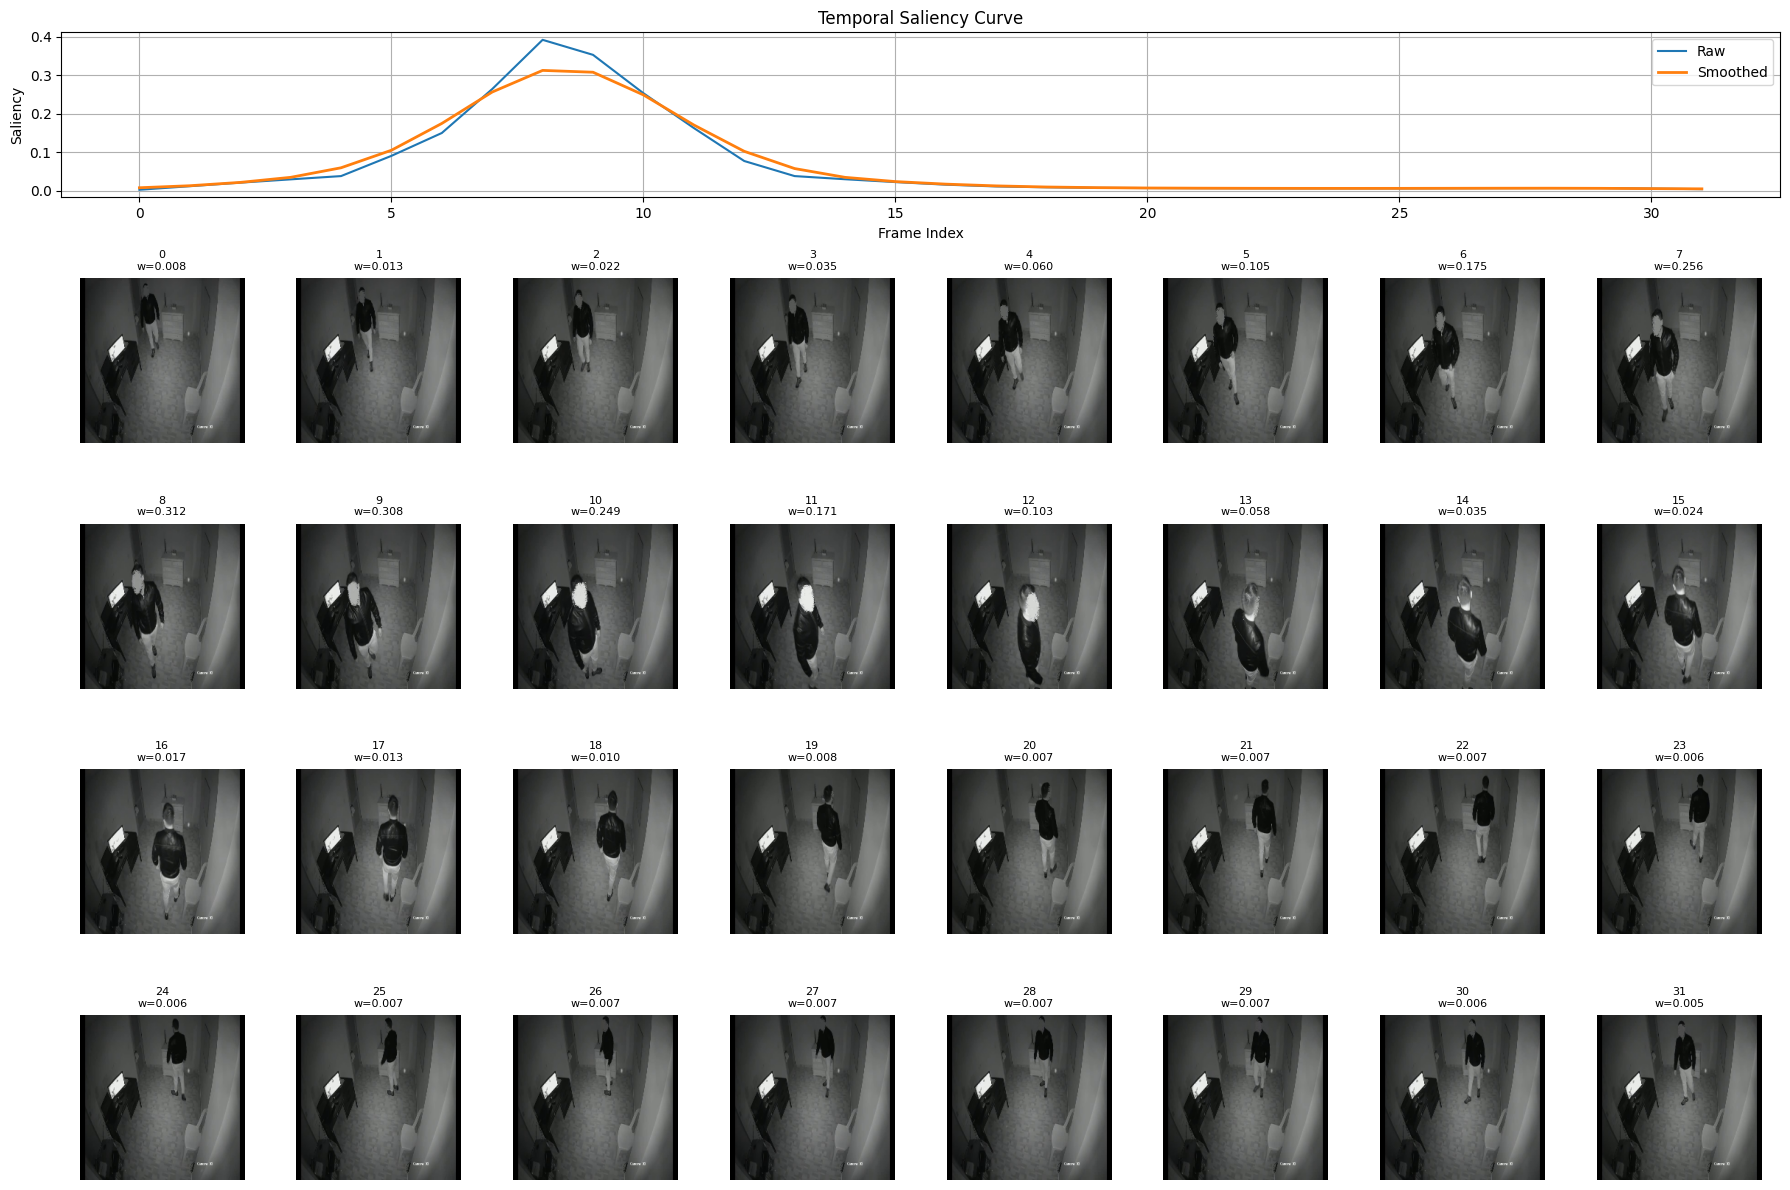

Saved as saliency_visualization.png
Status: Global Event Zone | Window: 6 to 11 | Varying K: 6


In [92]:


# =====================================================
# CONFIG
# =====================================================
VIDEO_PATH = r"/content/CAUCA_FALL/Subject.6/Walk/WalkS6.avi"   # works for .avi or .mp4
CKPT_PATH  = r"/content/best_model_fold3.pth"

CLIP_LEN   = 32
FRAME_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# MODEL
# =====================================================
class Stage1_3DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv3d(3,64,(3,7,7),(1,2,2),(1,3,3),padding_mode='replicate')
        self.bn1 = nn.BatchNorm3d(64)
        self.pool1 = nn.MaxPool3d((1,3,3),(1,2,2),(0,1,1))

        self.conv2 = nn.Conv3d(64,128,3, padding=1, padding_mode='replicate')
        self.bn2 = nn.BatchNorm3d(128)
        self.pool2 = nn.MaxPool3d(2,2)

        self.conv3 = nn.Conv3d(128,256,3,padding=1, padding_mode='replicate')
        self.bn3 = nn.BatchNorm3d(256)

        self.conv4 = nn.Conv3d(256,256,3,padding=1, padding_mode='replicate')
        self.bn4 = nn.BatchNorm3d(256)

        self.global_pool = nn.AdaptiveAvgPool3d((1,1,1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256,2)

    def forward(self,x, return_saliency=False):

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))   # <-- saliency layer

       # --- SALIENCY (Improved with Edge Gating) ---
        sal = x.detach().pow(2).mean(dim=(1,3,4))  # (B, T')

        # Create a mask to dampen the very first and last temporal indices
        # T' is likely 16 here because of pool2
        T_prime = sal.shape[1]
        mask = torch.ones(T_prime).to(sal.device)
        mask[0] = 0.05  # Strongly suppress the first frame index
        mask[-1] = 0.5  # Slightly suppress the last
        sal = sal * mask

        # Now apply your scaling
        min_val = sal.min(dim=1, keepdim=True)[0]
        max_val = sal.max(dim=1, keepdim=True)[0]
        sal = (sal - min_val) / (max_val - min_val + 1e-6)

        # Softmax with temperature (5.0) helps highlight the fall peak
        sal = F.softmax(sal * 5.0, dim=1)

        #sal  = sal / (sal.sum(dim=1, keepdim=True) + 1e-6)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.global_pool(x).flatten(1)
        x = self.dropout(x)
        logits = self.fc(x)

        if return_saliency:
            return logits, sal
        return logits

# =====================================================
# LOAD MODEL
# =====================================================
model = Stage1_3DCNN().to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# =====================================================
# UNIFORM SAMPLING
# =====================================================
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), "Cannot open video"

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
assert total_frames > 0, "Empty video"

indices = np.linspace(0, total_frames-1, CLIP_LEN).astype(int)

frames = []
for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError("Frame read failed")

    frame = cv2.resize(frame, (FRAME_SIZE, FRAME_SIZE))
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame)

cap.release()

frames_np = np.array(frames).astype(np.float32) / 255.0
clip = torch.from_numpy(frames_np).permute(3,0,1,2).unsqueeze(0).to(DEVICE)

# =====================================================
# RUN MODEL
# =====================================================
with torch.no_grad():
    logits, saliency = model(clip, return_saliency=True)

saliency = saliency.squeeze(0).cpu().numpy()

# Interpolate from 16 → 32 (since pool2 halves T)
saliency_interp = np.interp(
    np.linspace(0, len(saliency)-1, CLIP_LEN),
    np.arange(len(saliency)),
    saliency
)

# Smooth curve
saliency_smooth = gaussian_filter1d(saliency_interp, sigma=1.2)

print("Logits:", logits.cpu().numpy())
print("Raw Saliency:", saliency_interp)

# =====================================================
# PLOT CLEANLY
# =====================================================
fig = plt.figure(figsize=(18,12))

# ---- Saliency Curve (Top Full Width) ----
ax_curve = plt.subplot(5, 1, 1)
ax_curve.plot(saliency_interp, label="Raw")
ax_curve.plot(saliency_smooth, linewidth=2, label="Smoothed")
ax_curve.set_title("Temporal Saliency Curve")
ax_curve.set_xlabel("Frame Index")
ax_curve.set_ylabel("Saliency")
ax_curve.legend()
ax_curve.grid(True)

# ---- Frame Grid (4 rows x 8 cols) ----
rows = 4
cols = 8

for i in range(CLIP_LEN):
    ax = plt.subplot(5, cols, cols + i + 1)
    ax.imshow(frames[i])
    ax.set_title(f"{i}\nw={saliency_smooth[i]:.3f}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("saliency_visualization.png", dpi=300)
plt.show()

print("Saved as saliency_visualization.png")

def get_global_active_window(saliency_values, energy_threshold=0.15):
    # 1. Standardize and find 'Active' frames
    # We use a lower multiplier (0.5) to be more inclusive of "pre-fall" motion
    threshold = np.mean(saliency_values) + (0.5 * np.std(saliency_values))
    is_active = saliency_values > threshold

    # 2. Label all contiguous islands
    from scipy.ndimage import label
    labels, num_features = label(is_active)

    if num_features == 0:
        return 0, len(saliency_values) - 1, "Static/Uniform"

    total_energy = np.sum(saliency_values)
    significant_indices = []

    # 3. Filter islands by Energy Contribution (Global Context)
    for i in range(1, num_features + 1):
        mask = (labels == i)
        region_energy = np.sum(saliency_values[mask])

        # If this peak is a significant part of the whole clip's motion
        if (region_energy / total_energy) > energy_threshold:
            significant_indices.extend(np.where(mask)[0])

    if not significant_indices:
        # Fallback to the single highest peak if nothing meets the energy threshold
        peak_idx = np.argmax(saliency_values)
        return max(0, peak_idx-2), min(len(saliency_values)-1, peak_idx+2), "Peak Only"

    # 4. The Global Varying K
    start = min(significant_indices)
    end = max(significant_indices)

    return start, end, "Global Event Zone"

# Example usage in your pipeline:
start, end, status = get_global_active_window(saliency_smooth)
varying_k = end - start + 1

print(f"Status: {status} | Window: {start} to {end} | Varying K: {varying_k}")




In [93]:
# =====================================================
# SAVE STAGE 1 OUTPUT FOR STAGE 2
# =====================================================

# Prepare the data dictionary
# We include original video path, the localized window,
# the importance weights, and the actual frame numbers sampled.
stage1_data = {
    "video_path": VIDEO_PATH,
    "active_window": [int(start), int(end)],
    "varying_k": int(varying_k),
    "detection_status": status,
    "saliency_weights": saliency_smooth.tolist(),
    "clip_indices": indices.tolist()  # Maps 0-31 indices to actual video frame numbers
}

# Define the output path
json_output_path = "/content/stage1_output.json"

# Write to JSON
with open(json_output_path, "w") as f:
    json.dump(stage1_data, f, indent=4)

print("\n" + "="*50)
print(f"STAGE 1 JSON GENERATED: {json_output_path}")
print(f"Status: {status}")
print(f"Target Window: Frames {start} to {end} (K={varying_k})")
print("="*50)


STAGE 1 JSON GENERATED: /content/stage1_output.json
Status: Global Event Zone
Target Window: Frames 6 to 11 (K=6)


In [94]:
# ====== STAGE-2: Pose estimation, skeleton visualization, stage2_output.json ======


# ---------- CONFIG ----------
STAGE1_JSON = "stage1_output.json"
STAGE2_JSON = "stage2_output.json"
VIS_DIR = "/content/stage2_vis"
os.makedirs(VIS_DIR, exist_ok=True)

YOLO_MODEL = "yolov8m-pose.pt"   # Medium model is robust for movement
IMGSZ = 640                     # Optimal size for YOLOv8 accuracy/speed
CONF = 0.1                      # Low threshold to catch blurred/difficult falls
IOU  = 0.5
NUM_KP = 17                     # COCO standard joints

# COCO Skeleton pairs for drawing connecting lines
SKELETON_LINES = [
    (5, 6), (5, 11), (6, 12), (11, 12),       # Torso
    (5, 7), (7, 9), (6, 8), (8, 10),           # Arms
    (11, 13), (13, 15), (12, 14), (14, 16),   # Legs
    (0, 1), (0, 2), (1, 3), (2, 4)             # Face
]

# ---------- load stage1 json ----------
if not os.path.exists(STAGE1_JSON):
    raise FileNotFoundError(f"{STAGE1_JSON} not found. Run Stage-1 first.")

with open(STAGE1_JSON, "r") as f:
    s1 = json.load(f)

VIDEO_PATH = s1["video_path"]
clip_indices = s1["clip_indices"]
active_window = s1["active_window"]
clip_start, clip_end = int(active_window[0]), int(active_window[1])
frame_numbers = [int(clip_indices[i]) for i in range(clip_start, clip_end+1)]


YOLO_MODEL = "yolov8m-pose.pt"
print("Loading YOLO model...")
model = YOLO(YOLO_MODEL)

# ---------- run inference and save overlays ----------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Cannot open video: " + VIDEO_PATH)

frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

detections_px = {}
bboxes_px = {}
scores = {}

print(f"Processing {len(frame_numbers)} frames from Stage-1 window...")

for fnum in frame_numbers:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fnum))
    ret, frame = cap.read()
    if not ret:
        detections_px[fnum], bboxes_px[fnum], scores[fnum] = None, None, 0.0
        continue

    # Inference
    results = model.predict(source=frame, imgsz=IMGSZ, conf=CONF, iou=IOU, verbose=False)
    vis = frame.copy()

    if len(results) > 0 and len(results[0].boxes) > 0:
        # Get best detection (highest confidence)
        best_idx = results[0].boxes.conf.argmax()
        kp_data = results[0].keypoints.data[best_idx].cpu().numpy() # (17, 3)
        bbox = results[0].boxes.xyxy[best_idx].cpu().numpy()      # [x1, y1, x2, y2]

        detections_px[fnum] = kp_data[:, :2]
        scores[fnum] = float(results[0].boxes.conf[best_idx])

        # Convert bbox to [cx, cy, w, h] for JSON consistency
        bboxes_px[fnum] = [
            float((bbox[0]+bbox[2])/2), float((bbox[1]+bbox[3])/2),
            float(bbox[2]-bbox[0]), float(bbox[3]-bbox[1])
        ]

        # --- DRAW SKELETON ---
        # 1. Draw Lines (Cyan)
        for start_j, end_j in SKELETON_LINES:
            pt1, pt2 = kp_data[start_j], kp_data[end_j]
            if pt1[2] > 0.3 and pt2[2] > 0.3: # Confidence gate for clean visual
                cv2.line(vis, (int(pt1[0]), int(pt1[1])), (int(pt2[0]), int(pt2[1])), (255, 255, 0), 2)

        # 2. Draw Keypoint Dots (Green/Pink)
        for i, (x, y, conf) in enumerate(kp_data):
            if conf > 0.3:
                color = (0, 255, 0) if i > 4 else (255, 0, 255) # Pink for face, green for body
                cv2.circle(vis, (int(x), int(y)), 4, color, -1)

        # 3. Draw Bounding Box (Red)
        cv2.rectangle(vis, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 0, 255), 2)
        cv2.putText(vis, f"Person {scores[fnum]:.2f}", (int(bbox[0]), int(bbox[1])-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
    else:
        detections_px[fnum], bboxes_px[fnum], scores[fnum] = None, None, 0.0

    save_path = os.path.join(VIS_DIR, f"frame_{fnum:05d}.png")
    cv2.imwrite(save_path, vis)

cap.release()

# ---------- normalize and interpolate ----------
def norm_kp(kp, W, H):
    if kp is None: return [[None, None]] * NUM_KP
    return [[float(x/W), float(y/H)] for x, y in kp]

detections_norm = {f: norm_kp(detections_px[f], frame_w, frame_h) for f in frame_numbers}
bboxes_norm = {}
for f in frame_numbers:
    bx = bboxes_px[f]
    bboxes_norm[f] = [bx[0]/frame_w, bx[1]/frame_h, bx[2]/frame_w, bx[3]/frame_h] if bx else [None]*4

# Linear interpolation to fill gaps where YOLO missed a person
def interpolate(frames, dets, num_kp=17):
    L = len(frames)
    xs, ys = np.full((L, num_kp), np.nan), np.full((L, num_kp), np.nan)
    for i, f in enumerate(frames):
        for j, pt in enumerate(dets[f]):
            if pt[0] is not None: xs[i,j], ys[i,j] = pt[0], pt[1]

    idx = np.arange(L)
    for j in range(num_kp):
        mask = ~np.isnan(xs[:,j])
        if mask.any():
            xs[:,j] = np.interp(idx, idx[mask], xs[mask,j])
            ys[:,j] = np.interp(idx, idx[mask], ys[mask,j])

    return {f: [[float(xs[i,j]), float(ys[i,j])] for j in range(num_kp)] for i, f in enumerate(frames)}

interp_results = interpolate(frame_numbers, detections_norm)

# ---------- compute physics features ----------
frame_data = []
prev_hip = None

for f in frame_numbers:
    kp = interp_results[f]
    # Indices: 5,6 Shld | 11,12 Hip
    m_sh = [(kp[5][0]+kp[6][0])/2, (kp[5][1]+kp[6][1])/2]
    m_hp = [(kp[11][0]+kp[12][0])/2, (kp[11][1]+kp[12][1])/2]

    # Feature 1: Tilt Angle
    tilt = abs(math.degrees(math.atan2(m_sh[0]-m_hp[0], -(m_sh[1]-m_hp[1]))))
    # Feature 2: Vertical Velocity (Y-diff)
    vel = float(m_hp[1] - prev_hip[1]) if prev_hip else 0.0
    prev_hip = m_hp
    # Feature 3: Aspect Ratio
    bx = bboxes_norm[f]
    hw = float(bx[3]/bx[2]) if bx[2] and bx[2] > 0 else 0.0
    # Feature 4: Ground Proximity (1.0 - Y_shoulder)
    gp = float(1.0 - m_sh[1])

    frame_data.append({
        "frame_idx": f,
        "keypoints": kp,
        "normalized_bbox": bx,
        "score": scores[f],
        "features": {"tilt_angle": tilt, "vertical_velocity": vel, "h_w_ratio": hw, "ground_proximity": gp}
    })

with open(STAGE2_JSON, "w") as f:
    json.dump({"frame_data": frame_data}, f, indent=2)

print(f"Stage-2 Complete. JSON saved. {len(frame_numbers)} skeletons drawn in {VIS_DIR}")

Loading YOLO model...
Processing 6 frames from Stage-1 window...
Stage-2 Complete. JSON saved. 6 skeletons drawn in /content/stage2_vis


In [95]:
# -------- CELL 3: Visualization — combine stage1_output.json + stage2 overlays into combined images --------
# Edit STAGE2_VIS_DIR if your Stage-2 overlays were saved elsewhere.



STAGE1_JSON = "stage1_output.json"
STAGE2_JSON = "stage2_output.json"
STAGE2_VIS_DIR = "/content/stage2_vis"   # change to local folder if you ran Stage-2 locally
OUT_DIR = "stage_results"
os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.exists(STAGE1_JSON):
    raise FileNotFoundError(f"{STAGE1_JSON} not found. Run Stage-1 quick inference (Cell 2 with GENERATE_SAMPLE_INFERENCE=True) or produce stage1_output.json.")

if not os.path.exists(STAGE2_JSON):
    print(f"Warning: {STAGE2_JSON} not found. You can still create combined images if stage2 overlays exist in {STAGE2_VIS_DIR} and you have stage1_output.json.")

with open(STAGE1_JSON, "r") as f:
    s1 = json.load(f)

clip_indices = s1.get("clip_indices")
active_window = s1.get("active_window")
saliency = np.array(s1.get("saliency_weights", [])) if s1.get("saliency_weights") else None

if clip_indices is None or active_window is None:
    raise ValueError("stage1_output.json missing keys clip_indices or active_window.")

clip_start, clip_end = int(active_window[0]), int(active_window[1])
clip_positions = list(range(clip_start, clip_end+1))
frame_numbers = [int(clip_indices[p]) for p in clip_positions]

# load stage2 mapping if available
frame_data_map = {}
if os.path.exists(STAGE2_JSON):
    with open(STAGE2_JSON, "r") as f:
        s2 = json.load(f)
    for entry in s2.get("frame_data", []):
        frame_data_map[int(entry["frame_idx"])] = entry

for cp, frame_num in zip(clip_positions, frame_numbers):
    overlay_path = os.path.join(STAGE2_VIS_DIR, f"frame_{frame_num:05d}.png")
    if not os.path.exists(overlay_path):
        print("Overlay missing for frame", frame_num, "at", overlay_path, "- skipping.")
        continue
    img = cv2.imread(overlay_path)[:,:,::-1]
    h,w,_ = img.shape

    # build small saliency strip (optional)
    if saliency is not None:
        norm = (saliency - saliency.min()) / (saliency.max()-saliency.min()+1e-8)
        strip = 255 * np.ones((80, w, 3), dtype=np.uint8)
        pts = [ (int(j*(w/len(norm))), 40 - int(norm[j]*30)) for j in range(len(norm)) ]
        for j in range(len(pts)-1):
            cv2.line(strip, pts[j], pts[j+1], (255,0,0), 2)
    else:
        strip = 255 * np.ones((80, w, 3), dtype=np.uint8)

    combined = np.vstack([img, strip])
    # annotate with stage2 features if present
    info = frame_data_map.get(frame_num)
    if info:
        feats = info.get("features", {})
        txt = f"Frame {frame_num} | tilt={feats.get('tilt_angle')} v_vel={feats.get('vertical_velocity')} h/w={feats.get('h_w_ratio')} gp={feats.get('ground_proximity')}"
    else:
        txt = f"Frame {frame_num} | no stage2 entry"
    cv2.putText(combined, txt, (10,20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

    out_path = os.path.join(OUT_DIR, f"combined_{frame_num:05d}.png")
    cv2.imwrite(out_path, combined[:,:,::-1])
    print("Saved combined:", out_path)

print("Visualization complete. Check folder:", OUT_DIR)

Saved combined: stage_results/combined_00051.png
Saved combined: stage_results/combined_00059.png
Saved combined: stage_results/combined_00068.png
Saved combined: stage_results/combined_00076.png
Saved combined: stage_results/combined_00085.png
Saved combined: stage_results/combined_00094.png
Visualization complete. Check folder: stage_results


In [96]:
#---------------------- STAGE 3: Inference Definition -----------------------

SEQ_LEN = 16
NUM_FEATURES = 38
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FallAttentionModel(nn.Module):
    def __init__(self):
        super(FallAttentionModel, self).__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=NUM_FEATURES,
            num_heads=2,
            batch_first=True
        )
        self.norm = nn.LayerNorm(NUM_FEATURES)
        self.fc = nn.Sequential(
            nn.Linear(NUM_FEATURES, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x, mask=None):
        # key_padding_mask=mask ensures the model ignores padded frames mathematically
        attn_out, attn_weights = self.attention(x, x, x, key_padding_mask=mask)

        x = self.norm(x + attn_out)

        if mask is not None:
            weights_mask = (~mask).unsqueeze(-1).float()
            x_masked = x * weights_mask
            x_mean = x_masked.sum(dim=1) / (weights_mask.sum(dim=1) + 1e-8)
        else:
            x_mean = torch.mean(x, dim=1)

        out = self.fc(x_mean)
        return out, attn_weights

def load_json_sequence(json_path):
    with open(json_path, 'r') as f:
        doc = json.load(f)

    frames = doc.get("frame_data", [])
    sequence = []
    frame_indices = []

    for fdata in frames:
        frame_indices.append(fdata.get("frame_idx", -1))
        kp = np.array(fdata["keypoints"], dtype=np.float32).flatten()
        feat = fdata.get("features", {})
        f_vec = [
            float(feat.get("tilt_angle", 0) or 0) / 180.0,
            float(feat.get("vertical_velocity", 0) or 0) / 100.0,
            float(feat.get("h_w_ratio", 0) or 0) / 5.0,
            float(feat.get("ground_proximity", 0) or 0)
        ]
        combined = np.nan_to_num(np.concatenate([kp, f_vec]), nan=0.0)
        sequence.append(combined)

    real_len = len(sequence)
    mask = torch.zeros(SEQ_LEN, dtype=torch.bool)

    sequence_np = np.array(sequence, dtype=np.float32)
    if real_len < SEQ_LEN:
        pad = np.zeros((SEQ_LEN - real_len, NUM_FEATURES))
        sequence_np = np.vstack([sequence_np, pad])
        mask[real_len:] = True
    else:
        sequence_np = sequence_np[:SEQ_LEN]
        real_len = SEQ_LEN

    return (
        torch.FloatTensor(sequence_np).unsqueeze(0).to(DEVICE),
        mask.unsqueeze(0).to(DEVICE),
        frames,
        frame_indices
    )

========== STAGE 3 RESULT ==========
Fall Certainty Score: 1.0000 (HIGH RISK)
Total Keyframes: 6
Logging weights to: stage3_output.json


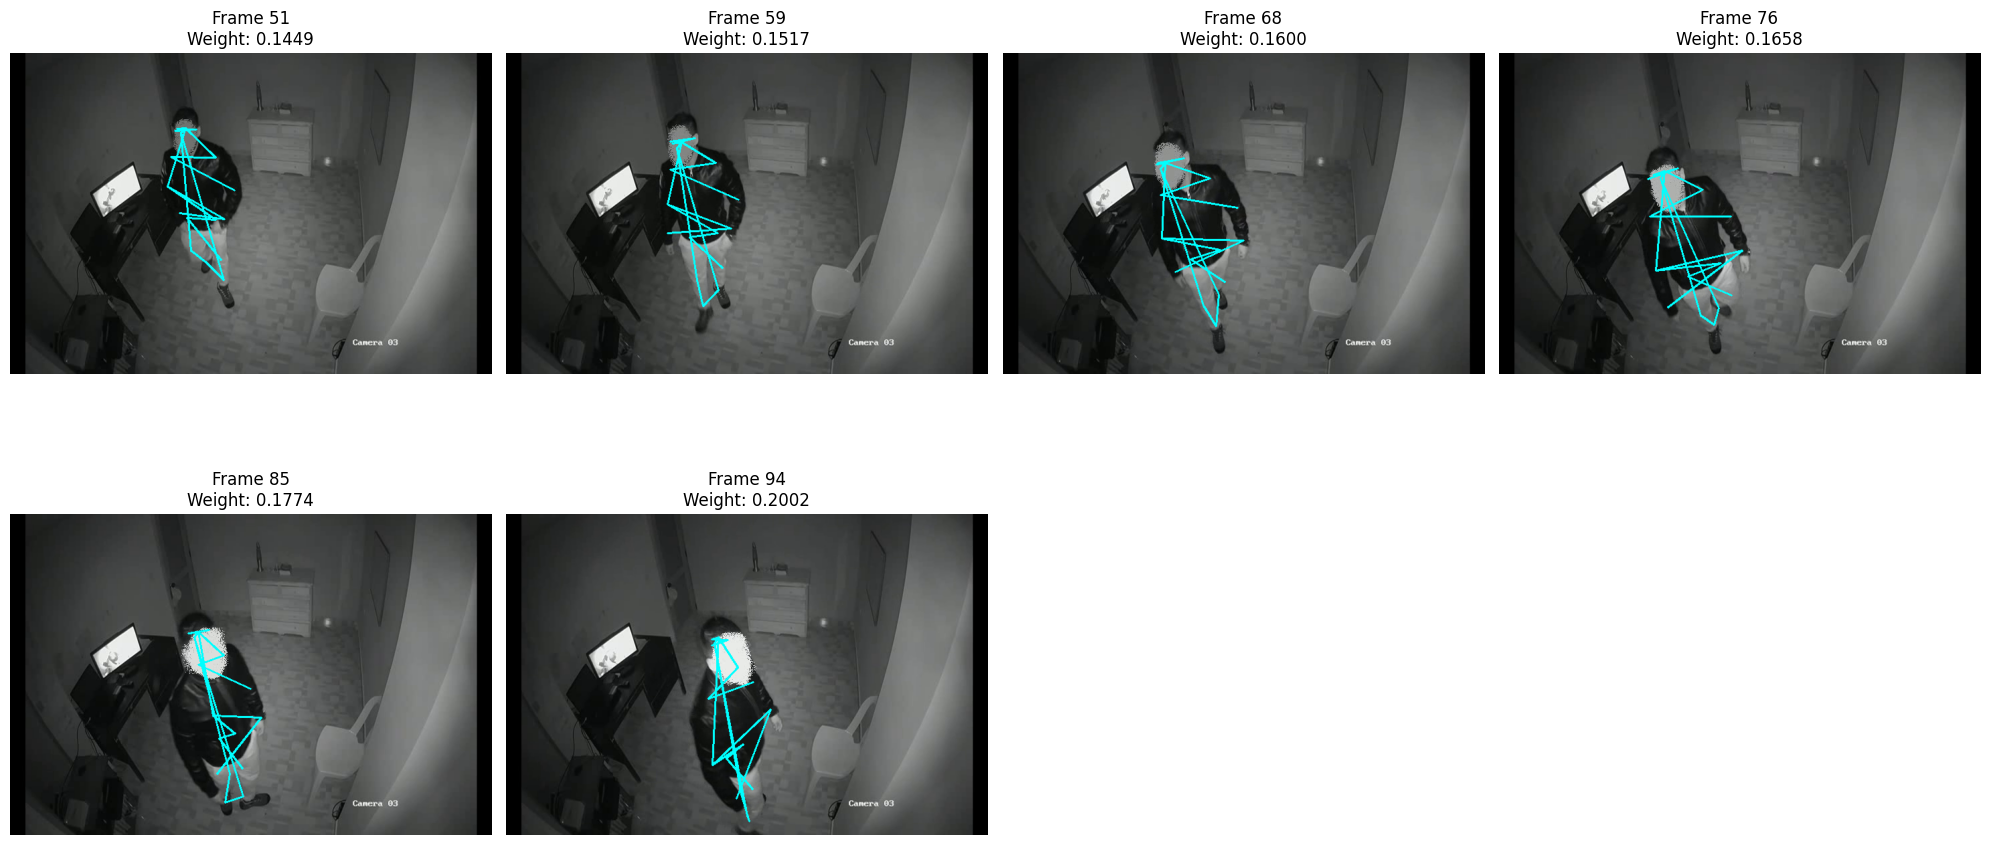

In [97]:



def visualize_stage3_all_frames(json_path, model_path, video_path, output_json="stage3_output.json"):
    # 1. Load Data
    x, mask, frame_entries, frame_indices = load_json_sequence(json_path)
    real_len = min(len(frame_entries), SEQ_LEN)

    # 2. Load Model
    model = FallAttentionModel().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # 3. Inference
    with torch.no_grad():
        prob, attn_weights = model(x, mask=mask)

    # Certainty Score / Fall Probability
    fall_prob = float(prob.item())
    risk_level = "HIGH" if fall_prob >= 0.75 else "MEDIUM" if fall_prob >= 0.45 else "LOW"

    # 4. Handle Attention Weights (Ensure only real frames share the weight)
    aw = attn_weights.cpu().numpy()
    if aw.ndim > 2:
        aw = np.mean(aw, axis=0) # Average across heads

    # Sum attention scores across the sequence and slice for real frames
    total_attn_scores = np.sum(aw, axis=0)
    attn_real = total_attn_scores[:real_len]

    # Re-normalize so padding gets exactly 0 and real frames sum to 1.0
    attn_norm = attn_real / (np.sum(attn_real) + 1e-8)

    # Logging Results
    print(f"========== STAGE 3 RESULT ==========")
    print(f"Fall Certainty Score: {fall_prob:.4f} ({risk_level} RISK)")
    print(f"Total Keyframes: {real_len}")
    print(f"Logging weights to: {output_json}")

    # 5. Export to JSON (Your specified format)
    # Using .tolist() to convert numpy arrays to JSON-serializable lists
    stage3_data = {
        "video_name": os.path.basename(video_path),
        "fall_probability": round(fall_prob, 4),
        "risk_level": risk_level,
        "keyframe_indices": [int(idx) for idx in frame_indices[:real_len]],
        "attention_weights": [round(float(w), 4) for w in attn_norm]
    }

    with open(output_json, 'w') as f:
        json.dump(stage3_data, f, indent=4)

    # 6. Dynamic Grid Plotting
    cols = 4
    rows = int(np.ceil(real_len / cols))

    cap = cv2.VideoCapture(video_path)
    SKELETON_CONNECTIONS = [
        (0,1),(1,2),(2,3),(3,4), (1,5),(5,6),(6,7), (1,8),(8,9),(9,10),
        (8,11),(11,12),(12,13), (0,14),(0,15),(14,16),(15,16)
    ]

    plt.figure(figsize=(20, 5 * rows))

    for idx in range(real_len):
        f_num = frame_indices[idx]
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(f_num))
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            h, w, _ = frame.shape
            kps = np.array(frame_entries[idx]["keypoints"])

            # Overlay Skeleton
            for (a, b) in SKELETON_CONNECTIONS:
                if a < len(kps) and b < len(kps):
                    pt1 = (int(kps[a][0] * w), int(kps[a][1] * h))
                    pt2 = (int(kps[b][0] * w), int(kps[b][1] * h))
                    cv2.line(frame, pt1, pt2, (0, 255, 255), 2)

            plt.subplot(rows, cols, idx + 1)
            plt.imshow(frame)
            plt.title(f"Frame {f_num}\nWeight: {attn_norm[idx]:.4f}")
            plt.axis('off')

    cap.release()
    plt.tight_layout()
    plt.show()

# Execution
# Ensure VIDEO_PATH is defined in your environment
visualize_stage3_all_frames(
    json_path="/content/stage2_output.json",
    model_path="/content/fall_model_fold_1.pth",
    video_path=VIDEO_PATH
)

In [98]:
# --------------------------------------
# LOAD STAGE 3 OUTPUT TO GET k*
# --------------------------------------


STAGE3_JSON_PATH = "/content/stage3_output.json"

with open(STAGE3_JSON_PATH, "r") as f:
    stage3_data = json.load(f)

keyframe_indices = stage3_data["keyframe_indices"]
attention_weights = stage3_data["attention_weights"]

k_star_idx = int(np.argmax(attention_weights))
selected_original_idx = keyframe_indices[k_star_idx]

print("Selected Original Frame (k*):", selected_original_idx)

Selected Original Frame (k*): 94


In [99]:
# -------------------- DEPTH MAP GENERATION ----------------------------

# ======================================
# CONFIG
# ======================================

VIDEO_PATH = VIDEO_PATH
OUTPUT_DIR = "depth_output"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume these are already defined before this block:
# selected_original_idx  -> k*
# total_frames           -> total frames in video

WINDOW_SIZE = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Using device:", DEVICE)

# ======================================
# LOAD MIDAS
# ======================================

print("Loading MiDaS model...")

midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.to(DEVICE)
midas.eval()

transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if "small" in "MiDaS_small":
    transform = transforms.small_transform
else:
    transform = transforms.default_transform

print("MiDaS loaded successfully.")

# ======================================
# OPEN VIDEO
# ======================================

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Error opening video file.")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Total frames in video:", total_frames)

# --------------------------------------
# Generate indices: 10 prior UNIFORM frames + selected
# --------------------------------------

# Load Stage 1 to get uniform 32 clip indices
with open("stage1_output.json", "r") as f:
    stage1_data = json.load(f)

clip_indices = stage1_data["clip_indices"]

# Find position of selected frame inside uniform clip_indices
depth_position = clip_indices.index(selected_original_idx)

# Select previous WINDOW_SIZE frames from uniform timeline
start_pos = max(0, depth_position - WINDOW_SIZE)
frame_indices = clip_indices[start_pos : depth_position + 1]

print("Generating depth for UNIFORM frame indices:", frame_indices)

# ======================================
# DEPTH GENERATION LOOP
# ======================================

for i, frame_idx in enumerate(frame_indices):

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ret, frame = cap.read()

    if not ret:
        print(f"Skipping frame {frame_idx}")
        continue

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_batch = transform(img).to(DEVICE)

    with torch.no_grad():
        prediction = midas(input_batch)

        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth = prediction.cpu().numpy()

    # Normalize depth to 0–255
    depth_min = depth.min()
    depth_max = depth.max()

    if depth_max - depth_min > 1e-6:
        depth = (depth - depth_min) / (depth_max - depth_min)
    else:
        depth = np.zeros_like(depth)

    depth_uint8 = (depth * 255).astype(np.uint8)

    # Save using original frame index
    output_path = os.path.join(OUTPUT_DIR, f"{frame_idx:06d}.jpg")
    cv2.imwrite(output_path, depth_uint8)

    print(f"Saved depth map for frame {frame_idx}")

cap.release()

print("\nDepth generation complete.")

Using device: cpu
Loading MiDaS model...


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


MiDaS loaded successfully.
Total frames in video: 266
Generating depth for UNIFORM frame indices: [8, 17, 25, 34, 42, 51, 59, 68, 76, 85, 94]
Saved depth map for frame 8
Saved depth map for frame 17
Saved depth map for frame 25
Saved depth map for frame 34
Saved depth map for frame 42
Saved depth map for frame 51
Saved depth map for frame 59
Saved depth map for frame 68
Saved depth map for frame 76
Saved depth map for frame 85
Saved depth map for frame 94

Depth generation complete.


In [100]:
import os
import json
import cv2
import numpy as np

# ==============================
# CONFIG
# ==============================

DEPTH_FOLDER = r"/content/depth_output"
STAGE2_JSON_PATH = r"/content/stage2_output.json"
STAGE3_JSON_PATH = r"/content/stage3_output.json"
STAGE4_OUTPUT_PATH = r"/content/stage4_output.json"

WINDOW_SIZE = 5

# ==============================
# HELPERS
# ==============================

def get_torso_centroid(keypoints, image_height, image_width):
    torso_ids = [5, 6, 11, 12]
    xs, ys = [], []
    for idx in torso_ids:
        x_norm, y_norm = keypoints[idx]
        xs.append(x_norm * image_width)
        ys.append(y_norm * image_height)
    return int(np.median(xs)), int(np.median(ys))


def weighted_average(values, weights):
    values = np.array(values)
    weights = np.array(weights)
    return np.sum(values * weights) / (np.sum(weights) + 1e-6)


# ==============================
# MAIN
# ==============================

def run_stage4():

    print("\n========== STAGE 4 REDESIGNED START ==========\n")

    # Load Stage 2 and 3
    with open(STAGE2_JSON_PATH, "r") as f:
        stage2_data = json.load(f)

    with open(STAGE3_JSON_PATH, "r") as f:
        stage3_data = json.load(f)

    keyframe_indices = stage3_data["keyframe_indices"]
    attention_weights = stage3_data["attention_weights"]

    # Normalize attention just in case
    attention_weights = np.array(attention_weights)
    attention_weights = attention_weights / (np.sum(attention_weights) + 1e-6)

    print("Video:", stage3_data["video_name"])
    print("Keyframes:", keyframe_indices)
    print("Attention Weights:", attention_weights.tolist())

    frame_lookup = {fd["frame_idx"]: fd for fd in stage2_data["frame_data"]}

    tilt_list = []
    hwr_list = []
    vel_list = []
    gp_list = []
    depth_list = []

    # ==============================
    # PROCESS EACH KEYFRAME
    # ==============================

    for i, frame_idx in enumerate(keyframe_indices):

        if frame_idx not in frame_lookup:
            continue

        frame_data = frame_lookup[frame_idx]
        features = frame_data["features"]

        tilt = features["tilt_angle"]
        hwr = features["h_w_ratio"]
        vel = features["vertical_velocity"]
        gp = features["ground_proximity"]

        tilt_list.append(tilt)
        hwr_list.append(hwr)
        vel_list.append(vel)
        gp_list.append(gp)

        # ---- Depth ----
        depth_path = os.path.join(DEPTH_FOLDER, f"{frame_idx:06d}.jpg")
        if os.path.exists(depth_path):
            depth_img = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE)
            depth_img = depth_img.astype(np.float32) / 255.0
            h, w = depth_img.shape

            x, y = get_torso_centroid(frame_data["keypoints"], h, w)

            if 0 <= x < w and 0 <= y < h:
                depth_val = depth_img[y, x]
            else:
                depth_val = 0.0
        else:
            depth_val = 0.0

        depth_list.append(depth_val)

        print(f"Frame {frame_idx} | Tilt={tilt:.2f} | HWR={hwr:.2f} | Depth={depth_val:.4f}")

    # ==============================
    # TEMPORAL STATISTICS
    # ==============================

    max_tilt = float(np.max(tilt_list))
    min_hwr = float(np.min(hwr_list))
    delta_tilt = float(tilt_list[-1] - tilt_list[0])
    delta_hwr = float(hwr_list[-1] - hwr_list[0])

    weighted_tilt = float(weighted_average(tilt_list, attention_weights))
    weighted_hwr = float(weighted_average(hwr_list, attention_weights))
    weighted_velocity = float(weighted_average(vel_list, attention_weights))
    weighted_gp = float(weighted_average(gp_list, attention_weights))

    depth_array = np.array(depth_list)
    depth_variance = float(np.var(depth_array))
    depth_range = float(np.max(depth_array) - np.min(depth_array))
    depth_drop = float(np.mean(depth_array[:-1]) - depth_array[-1]) if len(depth_array) > 1 else 0.0

    print("\n===== TEMPORAL SUMMARY =====")
    print("Max Tilt:", max_tilt)
    print("Delta Tilt:", delta_tilt)
    print("Min H/W Ratio:", min_hwr)
    print("Delta H/W Ratio:", delta_hwr)
    print("Weighted Tilt:", weighted_tilt)
    print("Weighted Velocity:", weighted_velocity)
    print("Weighted Ground Proximity:", weighted_gp)
    print("Depth Drop:", depth_drop)
    print("Depth Variance:", depth_variance)
    print("Depth Range:", depth_range)

    # ==============================
    # OUTPUT JSON
    # ==============================

    output_data = {
        "video_name": stage3_data["video_name"],
        "max_tilt": max_tilt,
        "delta_tilt": delta_tilt,
        "min_h_w_ratio": min_hwr,
        "delta_h_w_ratio": delta_hwr,
        "weighted_tilt": weighted_tilt,
        "weighted_velocity": weighted_velocity,
        "weighted_ground_proximity": weighted_gp,
        "depth_drop": depth_drop,
        "depth_variance": depth_variance,
        "depth_range": depth_range
    }

    with open(STAGE4_OUTPUT_PATH, "w") as f:
        json.dump(output_data, f, indent=4)

    print("\nStage 4 JSON saved at:", STAGE4_OUTPUT_PATH)
    print("\n========== STAGE 4 REDESIGNED END ==========\n")


if __name__ == "__main__":
    run_stage4()


========== STAGE 4 REDESIGNED START ==========

Video: WalkS6.avi
Keyframes: [51, 59, 68, 76, 85, 94]
Attention Weights: [0.14489985510014491, 0.1516998483001517, 0.15999984000016002, 0.1657998342001658, 0.17739982260017742, 0.2001997998002002]
Frame 51 | Tilt=4.95 | HWR=3.67 | Depth=0.3529
Frame 59 | Tilt=5.85 | HWR=3.71 | Depth=0.2824
Frame 68 | Tilt=11.08 | HWR=3.36 | Depth=0.2980
Frame 76 | Tilt=15.54 | HWR=2.74 | Depth=0.1765
Frame 85 | Tilt=8.08 | HWR=3.00 | Depth=0.1922
Frame 94 | Tilt=6.81 | HWR=3.45 | Depth=0.3922

===== TEMPORAL SUMMARY =====
Max Tilt: 15.543920941623398
Delta Tilt: 1.8602163093877913
Min H/W Ratio: 2.736508913619834
Delta H/W Ratio: -0.22008025200367953
Weighted Tilt: 8.752072233934163
Weighted Velocity: 0.03754991101422323
Weighted Ground Proximity: 0.5689469415616825
Depth Drop: -0.13176468014717102
Depth Variance: 0.006105344742536545
Depth Range: 0.21568627655506134

Stage 4 JSON saved at: /content/stage4_output.json

========== STAGE 4 REDESIGNED END =

In [101]:
import json
import numpy as np

# ==============================
# CONFIG (Physics Thresholds)
# ==============================

STAGE4_JSON_PATH = "/content/stage4_output.json"

T_MAX_TILT = 30.0          # degrees
T_DELTA_TILT = 20.0        # degrees change
T_MIN_HWR = 1.5            # near horizontal
T_DELTA_HWR = -1.5         # large structural drop

def run_stage5():

    print("\n========== STAGE 5 (PHYSICS BASED) START ==========\n")

    with open(STAGE4_JSON_PATH, "r") as f:
        data = json.load(f)

    max_tilt = data["max_tilt"]
    delta_tilt = data["delta_tilt"]
    min_hwr = data["min_h_w_ratio"]
    delta_hwr = data["delta_h_w_ratio"]
    depth_drop = data["depth_drop"]
    depth_variance = data["depth_variance"]

    print("Max Tilt:", max_tilt)
    print("Delta Tilt:", delta_tilt)
    print("Min H/W Ratio:", min_hwr)
    print("Delta H/W Ratio:", delta_hwr)
    print("Depth Drop:", depth_drop)
    print("Depth Variance:", depth_variance)

    # ==============================
    # RULES
    # ==============================

    rule1_rotation = max_tilt > T_MAX_TILT
    rule2_instability = delta_tilt > T_DELTA_TILT
    rule3_collapse = min_hwr < T_MIN_HWR
    rule4_shape_change = delta_hwr < T_DELTA_HWR

    print("\nRule 1 (Strong Rotation):", rule1_rotation)
    print("Rule 2 (Rapid Tilt Change):", rule2_instability)
    print("Rule 3 (Horizontal Body):", rule3_collapse)
    print("Rule 4 (Structural Collapse):", rule4_shape_change)

    # ==============================
    # DECISION LOGIC
    # ==============================

    score = sum([
        rule1_rotation,
        rule2_instability,
        rule3_collapse,
        rule4_shape_change
    ])

    if score >= 3:
        decision = "FALL"
    else:
        decision = "NO_FALL"

    print("\nFall Score:", score, "/ 4")
    print("Final Decision:", decision)

    print("\n========== STAGE 5 END ==========\n")


if __name__ == "__main__":
    run_stage5()


========== STAGE 5 (PHYSICS BASED) START ==========

Max Tilt: 15.543920941623398
Delta Tilt: 1.8602163093877913
Min H/W Ratio: 2.736508913619834
Delta H/W Ratio: -0.22008025200367953
Depth Drop: -0.13176468014717102
Depth Variance: 0.006105344742536545

Rule 1 (Strong Rotation): False
Rule 2 (Rapid Tilt Change): False
Rule 3 (Horizontal Body): False
Rule 4 (Structural Collapse): False

Fall Score: 0 / 4
Final Decision: NO_FALL

========== STAGE 5 END ==========

